# Teil 2 - data_description

In diesem Notebook bearbeite ich nur **Teil 2** der LB. Ich verwende hier nur einfache Python-Mittel. Ich lese die CSV-Datei ein, waehle ein Ziel-Feld, berechne einfache Statistiken, erstelle eine Grafik und skaliere ein Zahlenfeld.

In [1]:
import csv
import statistics
from collections import Counter
import matplotlib.pyplot as plt

dateiname = 'Smartphone_Usage_Productivity_Dataset_50000.csv'

ganzzahlen = {
    'Age',
    'Work_Productivity_Score',
    'Stress_Level',
    'App_Usage_Count',
    'Caffeine_Intake_Cups'
}

kommazahlen = {
    'Daily_Phone_Hours',
    'Social_Media_Hours',
    'Sleep_Hours',
    'Weekend_Screen_Time_Hours'
}

def wert_umwandeln(text, feld):
    if text == '':
        return None
    if feld in ganzzahlen:
        return int(text)
    if feld in kommazahlen:
        return float(text)
    return text

daten = []
with open(dateiname, newline='', encoding='utf-8') as datei:
    reader = csv.DictReader(datei, delimiter=';')
    spalten = reader.fieldnames
    for zeile in reader:
        neue_zeile = {}
        for feld, wert in zeile.items():
            neue_zeile[feld] = wert_umwandeln(wert, feld)
        daten.append(neue_zeile)

print('Zeilen:', len(daten))
print('Spalten:', len(spalten))
print('Spaltennamen:', spalten)
daten[:3]

Zeilen: 50000
Spalten: 13
Spaltennamen: ['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours']


[{'User_ID': 'U1',
  'Age': 58,
  'Gender': 'Male',
  'Occupation': 'Professional',
  'Device_Type': 'Android',
  'Daily_Phone_Hours': 1.3,
  'Social_Media_Hours': 6.7,
  'Work_Productivity_Score': 6,
  'Sleep_Hours': 8.8,
  'Stress_Level': 4,
  'App_Usage_Count': 42,
  'Caffeine_Intake_Cups': 1,
  'Weekend_Screen_Time_Hours': 8.7},
 {'User_ID': 'U2',
  'Age': 25,
  'Gender': 'Male',
  'Occupation': 'Professional',
  'Device_Type': 'Android',
  'Daily_Phone_Hours': 1.2,
  'Social_Media_Hours': 1.5,
  'Work_Productivity_Score': 5,
  'Sleep_Hours': 6.4,
  'Stress_Level': 1,
  'App_Usage_Count': 51,
  'Caffeine_Intake_Cups': 3,
  'Weekend_Screen_Time_Hours': 5.1},
 {'User_ID': 'U3',
  'Age': 19,
  'Gender': 'Male',
  'Occupation': 'Student',
  'Device_Type': 'iOS',
  'Daily_Phone_Hours': 5.3,
  'Social_Media_Hours': 5.7,
  'Work_Productivity_Score': 5,
  'Sleep_Hours': 9.0,
  'Stress_Level': 4,
  'App_Usage_Count': 14,
  'Caffeine_Intake_Cups': 5,
  'Weekend_Screen_Time_Hours': 6.3}]

## 2.1 Welches Feld moechte ich vorhersagen?

Ich moechte spaeter das Feld **`Work_Productivity_Score`** vorhersagen. Ich habe dieses Feld gewaehlt, weil es zeigt, wie produktiv eine Person ist. Andere Felder wie Alter, Handyzeit, Schlaf oder Stress koennten helfen, diesen Wert spaeter zu berechnen.

In [2]:
ziel_feld = 'Work_Productivity_Score'
print('Mein Ziel-Feld ist:', ziel_feld)
print('Erste 10 Werte von diesem Feld:')
[zeile[ziel_feld] for zeile in daten[:10]]

Mein Ziel-Feld ist: Work_Productivity_Score
Erste 10 Werte von diesem Feld:


[6, 5, 5, 2, 4, 9, 8, 4, 3, 1]

## 2.2 Einfache statistische Informationen

Bei den Zahlenfeldern berechne ich Mittelwert, Median, Standardabweichung, Minimum und Maximum. Bei den Textfeldern schaue ich, wie viele verschiedene Werte es gibt und welcher Wert am haeufigsten vorkommt.

In [3]:
zahlenfelder = [
    'Age',
    'Daily_Phone_Hours',
    'Social_Media_Hours',
    'Work_Productivity_Score',
    'Sleep_Hours',
    'Stress_Level',
    'App_Usage_Count',
    'Caffeine_Intake_Cups',
    'Weekend_Screen_Time_Hours'
]

for feld in zahlenfelder:
    werte = [zeile[feld] for zeile in daten if zeile[feld] is not None]
    print(f'\n{feld}')
    print('  Mittelwert:', round(statistics.mean(werte), 2))
    print('  Median:', round(statistics.median(werte), 2))
    print('  Standardabweichung:', round(statistics.stdev(werte), 2))
    print('  Minimum:', min(werte))
    print('  Maximum:', max(werte))


Age
  Mittelwert: 39.03
  Median: 39.0
  Standardabweichung: 12.41
  Minimum: 18
  Maximum: 60

Daily_Phone_Hours
  Mittelwert: 6.51
  Median: 6.5
  Standardabweichung: 3.17
  Minimum: 1.0
  Maximum: 12.0

Social_Media_Hours
  Mittelwert: 4.27
  Median: 4.3
  Standardabweichung: 2.16
  Minimum: 0.5
  Maximum: 8.0

Work_Productivity_Score
  Mittelwert: 5.5
  Median: 5.5
  Standardabweichung: 2.87
  Minimum: 1
  Maximum: 10

Sleep_Hours
  Mittelwert: 6.5
  Median: 6.5
  Standardabweichung: 1.45
  Minimum: 4.0
  Maximum: 9.0

Stress_Level
  Mittelwert: 5.5
  Median: 6.0
  Standardabweichung: 2.87
  Minimum: 1
  Maximum: 10

App_Usage_Count
  Mittelwert: 32.44
  Median: 32.0
  Standardabweichung: 16.12
  Minimum: 5
  Maximum: 60

Caffeine_Intake_Cups
  Mittelwert: 3.0
  Median: 3.0
  Standardabweichung: 2.0
  Minimum: 0
  Maximum: 6

Weekend_Screen_Time_Hours


  Mittelwert: 8.01
  Median: 8.0
  Standardabweichung: 3.46
  Minimum: 2.0
  Maximum: 14.0


In [4]:
textfelder = ['User_ID', 'Gender', 'Occupation', 'Device_Type']

for feld in textfelder:
    werte = [zeile[feld] for zeile in daten if zeile[feld] is not None]
    haeufigster_wert, anzahl = Counter(werte).most_common(1)[0]
    print(f'\n{feld}')
    print('  Verschiedene Werte:', len(set(werte)))
    print('  Haeufigster Wert:', haeufigster_wert)
    print('  Anzahl davon:', anzahl)


User_ID
  Verschiedene Werte: 50000
  Haeufigster Wert: U1
  Anzahl davon: 1

Gender
  Verschiedene Werte: 3
  Haeufigster Wert: Male
  Anzahl davon: 16708

Occupation
  Verschiedene Werte: 4
  Haeufigster Wert: Professional
  Anzahl davon: 12629

Device_Type
  Verschiedene Werte: 2
  Haeufigster Wert: Android
  Anzahl davon: 25080


In [5]:
print('Fehlende Werte pro Feld:')
for feld in spalten:
    fehlend = sum(1 for zeile in daten if zeile[feld] is None)
    print(f'{feld}:', fehlend)

Fehlende Werte pro Feld:
User_ID: 0
Age: 0
Gender: 0
Occupation: 0
Device_Type: 0
Daily_Phone_Hours: 0
Social_Media_Hours: 0
Work_Productivity_Score: 0
Sleep_Hours: 0
Stress_Level: 0
App_Usage_Count: 0
Caffeine_Intake_Cups: 0
Weekend_Screen_Time_Hours: 0


## 2.3 Eine einfache Grafik

Ich erstelle ein Histogramm fuer `Daily_Phone_Hours`. So sieht man, wie sich die taegliche Handy-Nutzung im Datensatz verteilt.

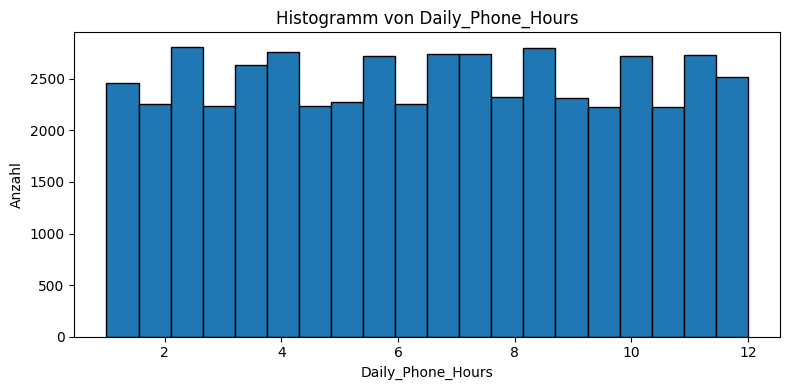

In [6]:
handy_stunden = [zeile['Daily_Phone_Hours'] for zeile in daten if zeile['Daily_Phone_Hours'] is not None]

plt.figure(figsize=(8, 4))
plt.hist(handy_stunden, bins=20, edgecolor='black')
plt.title('Histogramm von Daily_Phone_Hours')
plt.xlabel('Daily_Phone_Hours')
plt.ylabel('Anzahl')
plt.tight_layout()
plt.show()

## 2.4 Ein Datenfeld skalieren

Ich skaliere das Feld **`Daily_Phone_Hours`** auf einen Bereich von **0 bis 1**. Die Formel dafuer ist:

`(Wert - kleinster Wert) / (groesster Wert - kleinster Wert)`

Das ist einfach und gut verstaendlich.

In [7]:
original_werte = [zeile['Daily_Phone_Hours'] for zeile in daten if zeile['Daily_Phone_Hours'] is not None]
kleinster_wert = min(original_werte)
groesster_wert = max(original_werte)
bereich = groesster_wert - kleinster_wert

for zeile in daten:
    wert = zeile['Daily_Phone_Hours']
    if wert is None:
        zeile['Daily_Phone_Hours_0_1'] = None
    else:
        zeile['Daily_Phone_Hours_0_1'] = round((wert - kleinster_wert) / bereich, 4)

print('Minimum vorher:', kleinster_wert)
print('Maximum vorher:', groesster_wert)
print('Minimum nachher:', min(zeile['Daily_Phone_Hours_0_1'] for zeile in daten if zeile['Daily_Phone_Hours_0_1'] is not None))
print('Maximum nachher:', max(zeile['Daily_Phone_Hours_0_1'] for zeile in daten if zeile['Daily_Phone_Hours_0_1'] is not None))

vergleich = []
for zeile in daten[:10]:
    vergleich.append({
        'Daily_Phone_Hours': zeile['Daily_Phone_Hours'],
        'Daily_Phone_Hours_0_1': zeile['Daily_Phone_Hours_0_1']
    })

vergleich

Minimum vorher: 1.0
Maximum vorher: 12.0
Minimum nachher: 0.0
Maximum nachher: 1.0


[{'Daily_Phone_Hours': 1.3, 'Daily_Phone_Hours_0_1': 0.0273},
 {'Daily_Phone_Hours': 1.2, 'Daily_Phone_Hours_0_1': 0.0182},
 {'Daily_Phone_Hours': 5.3, 'Daily_Phone_Hours_0_1': 0.3909},
 {'Daily_Phone_Hours': 5.8, 'Daily_Phone_Hours_0_1': 0.4364},
 {'Daily_Phone_Hours': 7.9, 'Daily_Phone_Hours_0_1': 0.6273},
 {'Daily_Phone_Hours': 10.9, 'Daily_Phone_Hours_0_1': 0.9},
 {'Daily_Phone_Hours': 5.6, 'Daily_Phone_Hours_0_1': 0.4182},
 {'Daily_Phone_Hours': 8.5, 'Daily_Phone_Hours_0_1': 0.6818},
 {'Daily_Phone_Hours': 9.4, 'Daily_Phone_Hours_0_1': 0.7636},
 {'Daily_Phone_Hours': 2.8, 'Daily_Phone_Hours_0_1': 0.1636}]

## Kurzes Fazit

Ich habe ein Ziel-Feld fuer die spaetere Vorhersage ausgewaehlt, einfache Statistiken berechnet, eine Grafik erstellt und das Feld `Daily_Phone_Hours` auf 0 bis 1 skaliert. Damit ist Teil 2 einfach und verstaendlich umgesetzt.